# H&M Transactions EDA

Цель ноутбука: понять структуру и распределение данных до того, как делать сэмплинг для DataLens.

Файлы из [H&M Personalized Fashion Recommendations](https://www.kaggle.com/competitions/h-and-m-personalized-fashion-recommendations/data):
- `transactions_train.csv` — транзакции;
- `articles.csv` — каталог товаров;
- `customers.csv` — клиенты.

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

pd.set_option('display.max_columns', None)

COLOR_NEUTRAL = '#3A3A3A'
COLOR_ACCENT_GREEN = '#2E7D32' # для позитивного/растущего инсайта
COLOR_ACCENT_RED = '#C62828' # для аномалий и точек, требующих внимания
COLOR_SECONDARY = '#90A4AE'
COLOR_GRID = '#E0E0E0'

plt.rcParams.update({
    'figure.figsize': (11, 5),
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.edgecolor': '#CCCCCC',
    'axes.grid': True,
    'grid.color': COLOR_GRID,
    'grid.linewidth': 0.6,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.titlepad': 12,
})

def style_axis(ax, title):
    ax.set_title(title, loc='left', color='#1A1A1A')
    ax.set_xlabel('')
    ax.tick_params(colors='#555555')
    return ax

## 1. Размер файлов и быстрый просмотр

In [19]:
preview = pd.read_csv('transactions_train.csv', nrows=5)
preview

,t_dat,customer_id,article_id,price,sales_channel_id
0,2018-09-20,000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...,663713001,0.050831,2
1,2018-09-20,000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...,541518023,0.030492,2
2,2018-09-20,00007d2de826758b65a93dd24ce629ed66842531df6699...,505221004,0.015237,2
3,2018-09-20,00007d2de826758b65a93dd24ce629ed66842531df6699...,685687003,0.016932,2
4,2018-09-20,00007d2de826758b65a93dd24ce629ed66842531df6699...,685687004,0.016932,2


In [20]:
preview.dtypes

t_dat                   str
customer_id             str
article_id            int64
price               float64
sales_channel_id      int64
dtype: object

## 2. Загрузка полного датасета транзакций

In [4]:
df = pd.read_csv(
    'transactions_train.csv',
    usecols=['t_dat', 'customer_id', 'article_id', 'price', 'sales_channel_id'],
    parse_dates=['t_dat']
)

print(f'Строк: {len(df):,}')
print(f'Период: {df["t_dat"].min().date()} — {df["t_dat"].max().date()}')
df.head()

Строк: 31,788,324
Период: 2018-09-20 — 2020-09-22


,t_dat,customer_id,article_id,price,sales_channel_id
0,2018-09-20,000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...,663713001,0.050831,2
1,2018-09-20,000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...,541518023,0.030492,2
2,2018-09-20,00007d2de826758b65a93dd24ce629ed66842531df6699...,505221004,0.015237,2
3,2018-09-20,00007d2de826758b65a93dd24ce629ed66842531df6699...,685687003,0.016932,2
4,2018-09-20,00007d2de826758b65a93dd24ce629ed66842531df6699...,685687004,0.016932,2


In [5]:
articles = pd.read_csv('articles.csv')
print(f'Товаров в каталоге: {len(articles):,}')

Товаров в каталоге: 105,542


## 3. Базовая статистика

Смотрим распределение цены и наличие пропусков / аномалий.

In [6]:
df.describe()

,t_dat,article_id,price,sales_channel_id
count,31788324,3.178832e+07,3.178832e+07,3.178832e+07
mean,2019-09-15 17:27:46.894447,6.962272e+08,2.782927e-02,1.704028e+00
min,2018-09-20 00:00:00,1.087750e+08,1.694915e-05,1.000000e+00
25%,2019-03-28 00:00:00,6.328030e+08,1.581356e-02,1.000000e+00
50%,2019-08-25 00:00:00,7.145820e+08,2.540678e-02,2.000000e+00
75%,2020-03-29 00:00:00,7.865240e+08,3.388136e-02,2.000000e+00
max,2020-09-22 00:00:00,9.562170e+08,5.915254e-01,2.000000e+00
std,NaN,1.334480e+08,1.918113e-02,4.564786e-01


In [7]:
print('Пропуски по колонкам:')
print(df.isna().sum())
print()
print('Уникальных клиентов:', df['customer_id'].nunique())
print('Уникальных товаров:', df['article_id'].nunique())
print('Каналов продаж:', df['sales_channel_id'].unique())

Пропуски по колонкам:
t_dat               0
customer_id         0
article_id          0
price               0
sales_channel_id    0
dtype: int64

Уникальных клиентов: 1362281
Уникальных товаров: 104547
Каналов продаж: [2 1]


## 4. Количество транзакций по месяцам

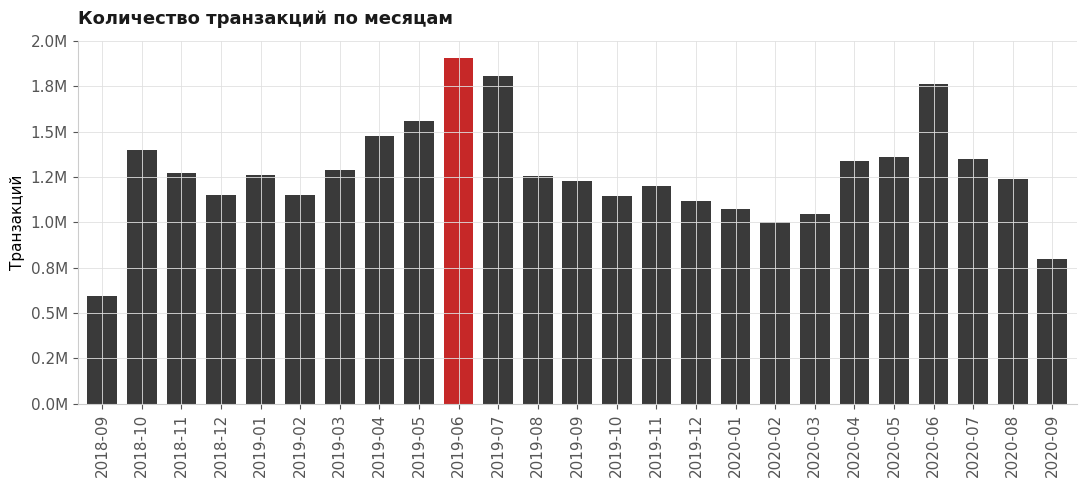

month
2018-09     594776
2018-10    1397040
2018-11    1270619
2018-12    1148827
2019-01    1263471
2019-02    1152412
2019-03    1286750
2019-04    1476454
2019-05    1560319
2019-06    1906202
2019-07    1807494
2019-08    1253530
2019-09    1227178
2019-10    1146772
2019-11    1198033
2019-12    1118315
2020-01    1076354
2020-02    1001859
2020-03    1047752
2020-04    1340882
2020-05    1361815
2020-06    1764507
2020-07    1351502
2020-08    1237192
2020-09     798269
Freq: M, dtype: int64

In [8]:
df['month'] = df['t_dat'].dt.to_period('M')

monthly_counts = df.groupby('month').size()

# Выделяем красным месяц с максимальным числом транзакций
peak_month = monthly_counts.idxmax()
colors = [COLOR_ACCENT_RED if m == peak_month else COLOR_NEUTRAL for m in monthly_counts.index]

fig, ax = plt.subplots()
monthly_counts.plot(kind='bar', color=colors, ax=ax, width=0.75)
style_axis(ax, 'Количество транзакций по месяцам')
ax.set_ylabel('Транзакций')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
ax.annotate(
    f'пик: {monthly_counts[peak_month]:,}',
    xy=(list(monthly_counts.index).index(peak_month), monthly_counts[peak_month]),
    xytext=(0, 12), textcoords='offset points',
    ha='center', color=COLOR_ACCENT_RED, fontweight='bold', fontsize=10
)
plt.tight_layout()
plt.show()

monthly_counts

## 5. Суммарный Price Index по месяцам

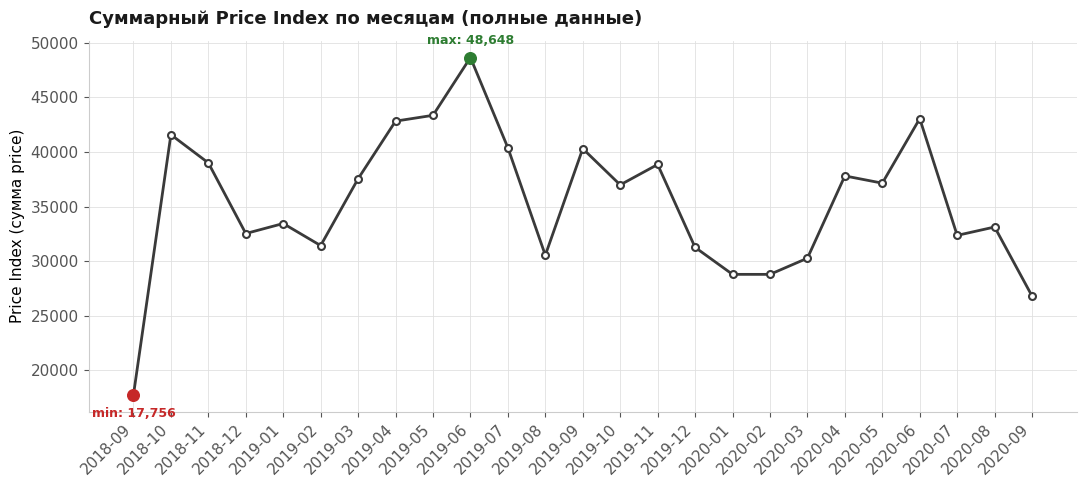

month
2018-09    17755.639593
2018-10    41584.816610
2018-11    39000.988390
2018-12    32532.514712
2019-01    33449.981475
2019-02    31428.221814
2019-03    37549.020169
2019-04    42824.987305
2019-05    43357.502322
2019-06    48648.417864
2019-07    40387.129373
2019-08    30545.846729
2019-09    40304.049864
2019-10    36987.708593
2019-11    38854.420000
2019-12    31267.592458
2020-01    28793.583492
2020-02    28792.876814
2020-03    30274.204661
2020-04    37808.485661
2020-05    37145.694373
2020-06    43055.359068
2020-07    32363.007169
2020-08    33130.499254
2020-09    26803.426288
Freq: M, Name: price, dtype: float64

In [9]:
monthly_revenue = df.groupby('month')['price'].sum()

fig, ax = plt.subplots()
ax.plot(monthly_revenue.index.astype(str), monthly_revenue.values,
        color=COLOR_NEUTRAL, linewidth=2, marker='o', markersize=5,
        markerfacecolor='white', markeredgewidth=1.5)

# Подсвечиваем максимум зелёным, минимум красным
max_idx, min_idx = monthly_revenue.idxmax(), monthly_revenue.idxmin()
for idx, color, label in [(max_idx, COLOR_ACCENT_GREEN, 'max'), (min_idx, COLOR_ACCENT_RED, 'min')]:
    pos = list(monthly_revenue.index).index(idx)
    ax.scatter(pos, monthly_revenue[idx], color=color, s=70, zorder=5)
    ax.annotate(f'{label}: {monthly_revenue[idx]:,.0f}', xy=(pos, monthly_revenue[idx]),
                xytext=(0, 10 if label == 'max' else -16), textcoords='offset points',
                ha='center', color=color, fontweight='bold', fontsize=9)

style_axis(ax, 'Суммарный Price Index по месяцам (полные данные)')
ax.set_ylabel('Price Index (сумма price)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

monthly_revenue

## 6. Распределение цены товаров

Проверяем, есть ли выбросы, которые могут искажать сумму при сэмплировании.

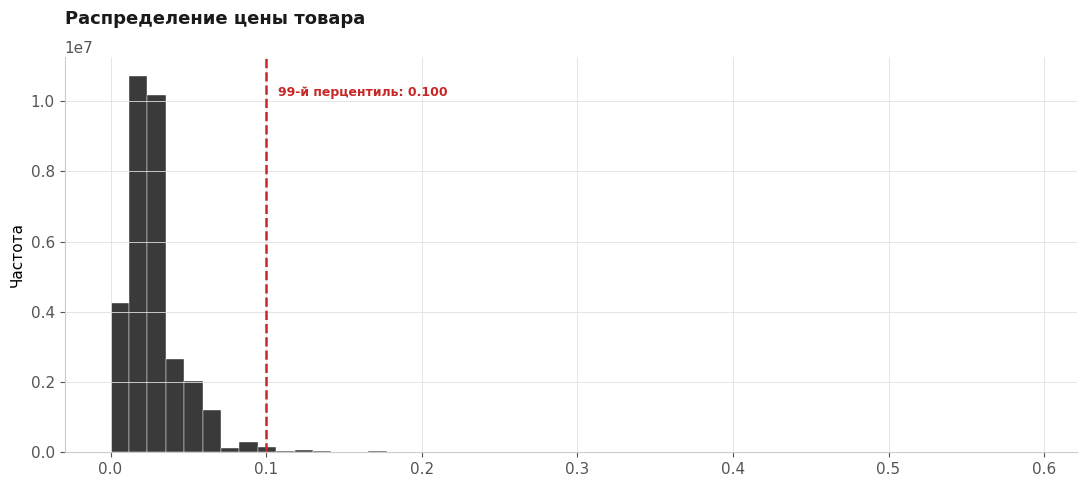

99-й перцентиль цены: 0.1002
Максимальная цена: 0.5915


In [10]:
p99 = df['price'].quantile(0.99)
p_max = df['price'].max()

fig, ax = plt.subplots()
ax.hist(df['price'], bins=50, color=COLOR_NEUTRAL, edgecolor='white', linewidth=0.3)
ax.axvline(p99, color=COLOR_ACCENT_RED, linewidth=1.8, linestyle='--')
ax.annotate(f'99-й перцентиль: {p99:.3f}', xy=(p99, ax.get_ylim()[1] * 0.9),
            xytext=(8, 0), textcoords='offset points',
            color=COLOR_ACCENT_RED, fontweight='bold', fontsize=9)
style_axis(ax, 'Распределение цены товара')
ax.set_ylabel('Частота')
plt.tight_layout()
plt.show()

print(f'99-й перцентиль цены: {p99:.4f}')
print(f'Максимальная цена: {p_max:.4f}')

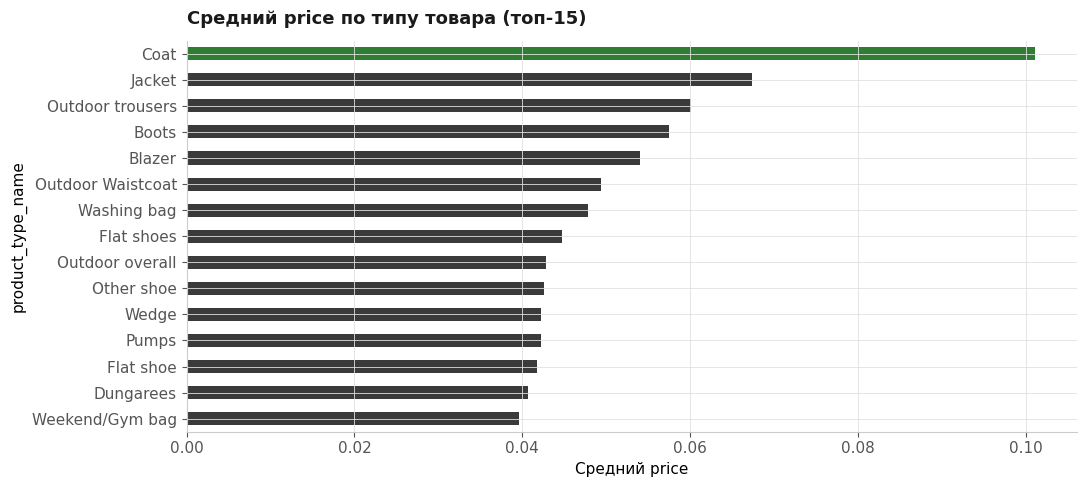

product_type_name
Coat                 0.101038
Jacket               0.067354
Outdoor trousers     0.060118
Boots                0.057472
Blazer               0.053979
Outdoor Waistcoat    0.049354
Washing bag          0.047786
Flat shoes           0.044786
Outdoor overall      0.042874
Other shoe           0.042628
Wedge                0.042282
Pumps                0.042249
Flat shoe            0.041740
Dungarees            0.040710
Weekend/Gym bag      0.039647
Name: price, dtype: float64

In [11]:
# Подтягиваем тип товара к каждой транзакции
df_with_type = df.merge(
    articles[['article_id', 'product_type_name', 'index_name']],
    on='article_id',
    how='left'
)

avg_price_by_type = (
    df_with_type.groupby('product_type_name')['price']
    .mean()
    .sort_values(ascending=False)
    .head(15)
)

colors = [COLOR_ACCENT_GREEN if i == 0 else COLOR_NEUTRAL for i in range(len(avg_price_by_type))]

fig, ax = plt.subplots()
avg_price_by_type[::-1].plot(kind='barh', color=colors[::-1], ax=ax)
style_axis(ax, 'Средний price по типу товара (топ-15)')
ax.set_xlabel('Средний price')
plt.tight_layout()
plt.show()

avg_price_by_type

Значения `price` лежат в диапазоне примерно 0.00–0.6, а средняя цена по категориям различается в разумных пропорциях (более дорогие категории вроде пальто/курток — выше). Это подтверждает, ЧТО `price` — нормализованная величина, а не цена в реальной валюте.

Поле используется как **Price Index**, без знака валюты. Сравнения между категориями и динамика во времени остаются валидными.

## 7. Каталог товаров (articles.csv)

In [12]:
articles[['article_id', 'product_type_name', 'colour_group_name', 'index_name']].head()

,article_id,product_type_name,colour_group_name,index_name
0,108775015,Vest top,Black,Ladieswear
1,108775044,Vest top,White,Ladieswear
2,108775051,Vest top,Off White,Ladieswear
3,110065001,Bra,Black,Lingeries/Tights
4,110065002,Bra,White,Lingeries/Tights


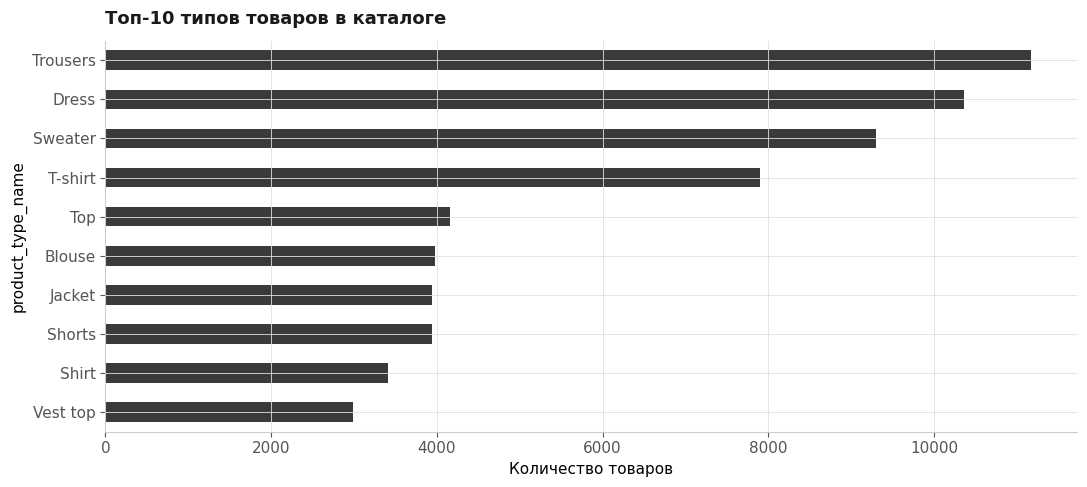

In [13]:
top_catalog = articles['product_type_name'].value_counts().head(10)

fig, ax = plt.subplots()
top_catalog[::-1].plot(kind='barh', color=COLOR_NEUTRAL, ax=ax)
style_axis(ax, 'Топ-10 типов товаров в каталоге')
ax.set_xlabel('Количество товаров')
plt.tight_layout()
plt.show()

На графике ниже: зелёным отмечены категории, которые входят и в топ каталога, и в топ продаж; красным — категории, которых нет в топ-10 каталога, но которые вошли в топ по Price Index. Демонстрирует разрыв между ассортиментом и спросом.

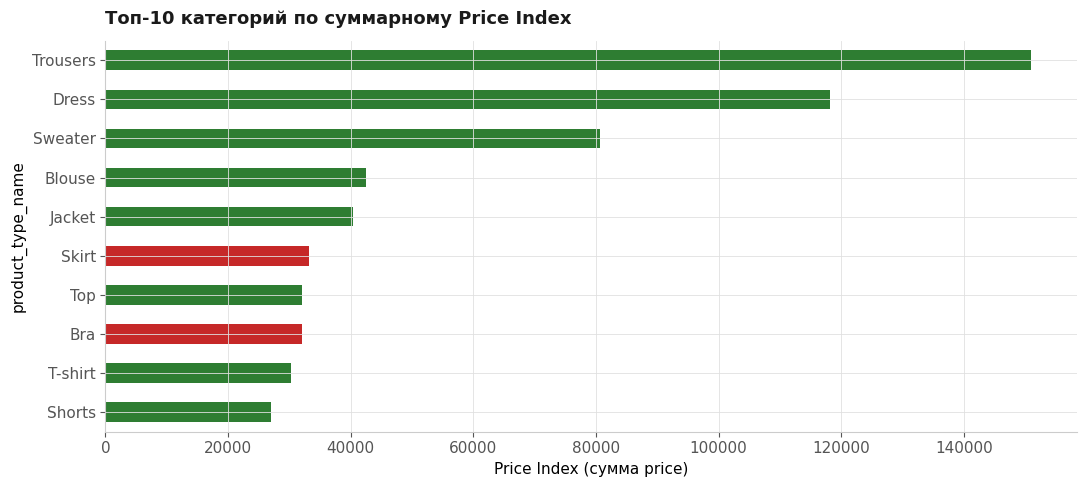

product_type_name
Trousers    150908.046237
Dress       118185.796576
Sweater      80732.982881
Blouse       42424.630475
Jacket       40422.762017
Skirt        33230.477051
Top          32120.533831
Bra          31987.636797
T-shirt      30274.877153
Shorts       26973.206153
Name: price, dtype: float64

In [14]:
top_by_revenue = (
    df_with_type.groupby('product_type_name')['price']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

catalog_top_set = set(top_catalog.index)
colors = [COLOR_ACCENT_RED if name not in catalog_top_set else COLOR_ACCENT_GREEN
          for name in top_by_revenue.index]

fig, ax = plt.subplots()
top_by_revenue[::-1].plot(kind='barh', color=colors[::-1], ax=ax)
style_axis(ax, 'Топ-10 категорий по суммарному Price Index')
ax.set_xlabel('Price Index (сумма price)')
plt.tight_layout()
plt.show()

top_by_revenue

## 8. Сезонность по дням недели

Помимо месячной сезонности (см. п.4), интересно посмотреть — есть ли разница в активности покупок по дням недели. Это типичный вопрос e-commerce аналитики (выходные vs будни).

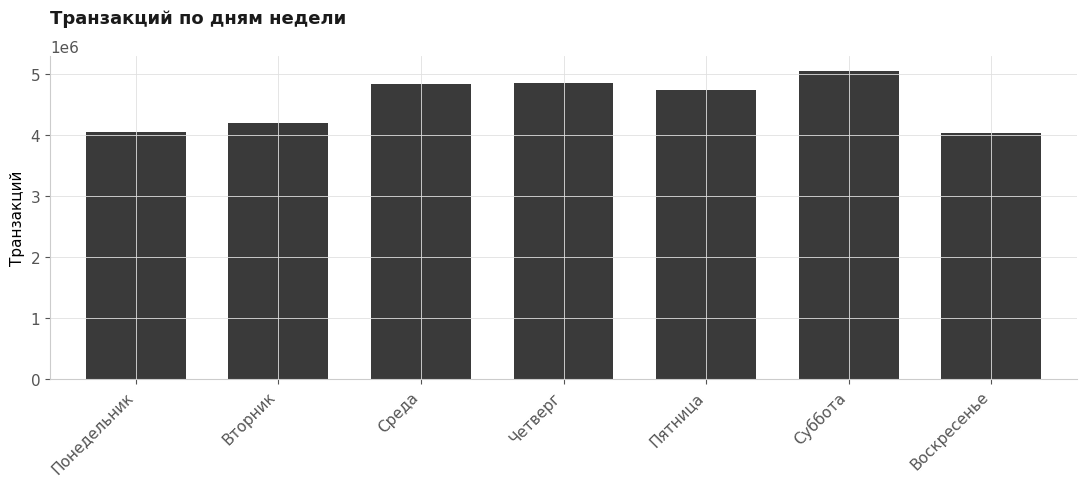

In [15]:
weekday_names = ['Понедельник', 'Вторник', 'Среда', 'Четверг', 'Пятница', 'Суббота', 'Воскресенье']
df['weekday'] = df['t_dat'].dt.dayofweek

weekday_counts = df.groupby('weekday').size()
weekday_counts.index = [weekday_names[i] for i in weekday_counts.index]

fig, ax = plt.subplots()
weekday_counts.plot(kind='bar', color=COLOR_NEUTRAL, ax=ax, width=0.7)
style_axis(ax, 'Транзакций по дням недели')
ax.set_ylabel('Транзакций')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 9. Клиенты (customers.csv)

Клиентов: 1,371,980

Пропуски в возрасте: 15861


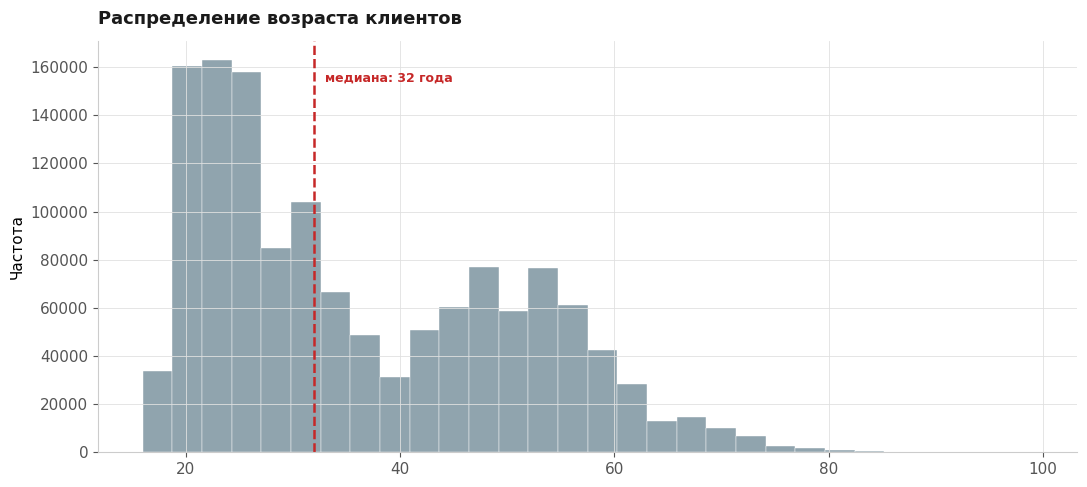

In [16]:
customers = pd.read_csv('customers.csv')
print(f'Клиентов: {len(customers):,}')
print()
print('Пропуски в возрасте:', customers['age'].isna().sum())

median_age = customers['age'].median()

fig, ax = plt.subplots()
ax.hist(customers['age'].dropna(), bins=30, color=COLOR_SECONDARY, edgecolor='white', linewidth=0.3)
ax.axvline(median_age, color=COLOR_ACCENT_RED, linewidth=1.8, linestyle='--')
ax.annotate(f'медиана: {median_age:.0f} года', xy=(median_age, ax.get_ylim()[1] * 0.9),
            xytext=(8, 0), textcoords='offset points',
            color=COLOR_ACCENT_RED, fontweight='bold', fontsize=9)
style_axis(ax, 'Распределение возраста клиентов')
ax.set_ylabel('Частота')
plt.tight_layout()
plt.show()

## 10. Стратегия сэмплирования

Возьмём пропорциональную выборку (`frac`) и сравним её помесячную форму с полными данными. Если линии повторяют друг друга по форме (с поправкой на масштаб) — стратегия рабочая.

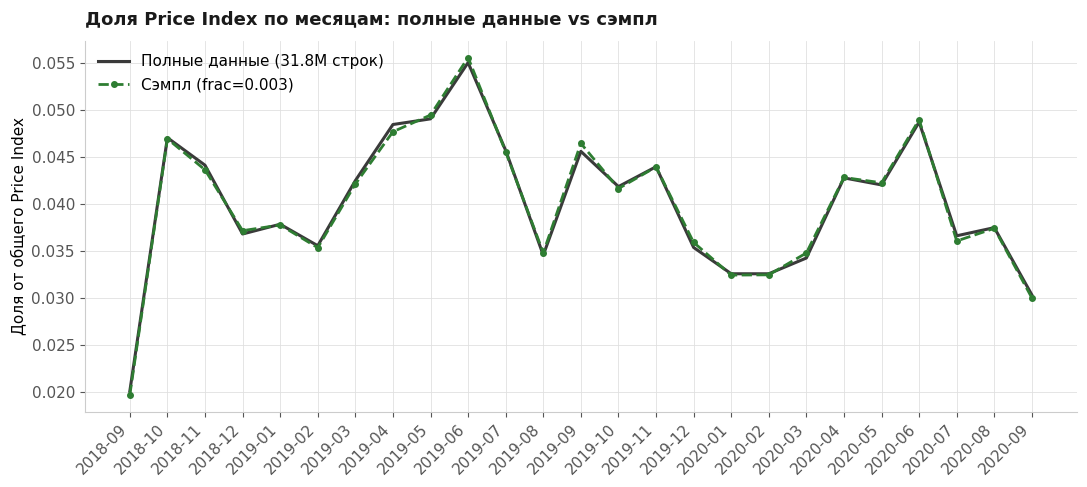

Размер сэмпла: 95,365 строк (0.30% от полных данных)


In [17]:
sample_frac = 0.003  # ~100k строк из ~31.8M
sampled_preview = df.groupby('month').sample(frac=sample_frac, random_state=42)

full_norm = monthly_revenue / monthly_revenue.sum()
sample_norm = sampled_preview.groupby('month')['price'].sum()
sample_norm = sample_norm / sample_norm.sum()

fig, ax = plt.subplots()
ax.plot(full_norm.index.astype(str), full_norm.values,
        color=COLOR_NEUTRAL, linewidth=2.2, label='Полные данные (31.8M строк)')
ax.plot(sample_norm.index.astype(str), sample_norm.values,
        color=COLOR_ACCENT_GREEN, linewidth=2, linestyle='--',
        marker='o', markersize=4, label=f'Сэмпл (frac={sample_frac})')

style_axis(ax, 'Доля Price Index по месяцам: полные данные vs сэмпл')
ax.set_ylabel('Доля от общего Price Index')
ax.legend(frameon=False, loc='upper left')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(f'Размер сэмпла: {len(sampled_preview):,} строк ({len(sampled_preview)/len(df):.2%} от полных данных)')

**Вывод:** линии совпадают по форме — сезонные пики и провалы сохраняются после сэмплирования. Пропорциональная выборка (`groupby('month').sample(frac=...)`) — корректный способ уменьшить датасет для DataLens без потери картины сезонности.

## 11. Итоговые выводы перед сэмплированием

1. Есть сезонность. Количество транзакций колеблется по месяцам с пиками в июне (п.4) — это похоже на сезонные распродажи, а не на линейный рост клиентской базы.
2. `price` — не реальная цена, а индекс. Далее используется как **Price Index**.
3. Выбросов по цене немного. (п.6) — 99-й перцентиль и максимум близки, единичные дорогие товары не должны сильно искажать сумму при случайном сэмплировании.
4. Самые многочисленные категории в каталоге (Trousers, Dress, Sweater — п.7) не обязательно совпадают с топом по Price Index (п.7.1).